In [ ]:




import tensorflow as tf # 3.12.9
import tensorflow_datasets as tfds


In [ ]:
print("Loading Food-101 dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    'food101',
    split=['train', 'validation'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")
print("Number of classes:", ds_info.features['label'].num_classes)

# Code 1 

Loading datasets from directory...
Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.

Sample training labels:


2025-07-08 02:06:22.281989: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 478 of 1000
2025-07-08 02:06:33.190243: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 571 of 1000
2025-07-08 02:06:53.082481: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 713 of 1000
2025-07-08 02:07:12.036677: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 873 of 1000
2025-07-08 02:07:22.116630: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 921 of 1000
2025-07-08 02:07:31.282565: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


[ 70  26  26  73  81  97  11  52 100  80  93  44  95  27  89  68  52   4
  84  31  74  17  19  37  86  72  24  51   1  35  41  83]

Sample validation labels:
[ 93  12  32  48  12  87  95  56  57  99  95  84  82  37  94  45  84  58
  52   3  31  80  86  24  56  39   7  99  13 100  52  36]

Creating model...


2025-07-08 02:07:35.252685: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "functional_3"

...

INFO:tensorflow:Assets written to: /var/folders/5r/_xy1410s2v79gzphw2rfltyh0000gn/T/tmp9o8b48la/assets


INFO:tensorflow:Assets written to: /var/folders/5r/_xy1410s2v79gzphw2rfltyh0000gn/T/tmp9o8b48la/assets


Saved artifact at '/var/folders/5r/_xy1410s2v79gzphw2rfltyh0000gn/T/tmp9o8b48la'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_329')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  13225121104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225122832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225122640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225122064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225123408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225122256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225123024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225123216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13225124368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322

W0000 00:00:1751959835.354542 8850320 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1751959835.354558 8850320 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-07-08 13:00:35.360443: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/5r/_xy1410s2v79gzphw2rfltyh0000gn/T/tmp9o8b48la
2025-07-08 13:00:35.367659: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-07-08 13:00:35.367669: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/5r/_xy1410s2v79gzphw2rfltyh0000gn/T/tmp9o8b48la
I0000 00:00:1751959835.449471 8850320 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-07-08 13:00:35.466973: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-07-08 13:00:35.963697: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder


Training completed!


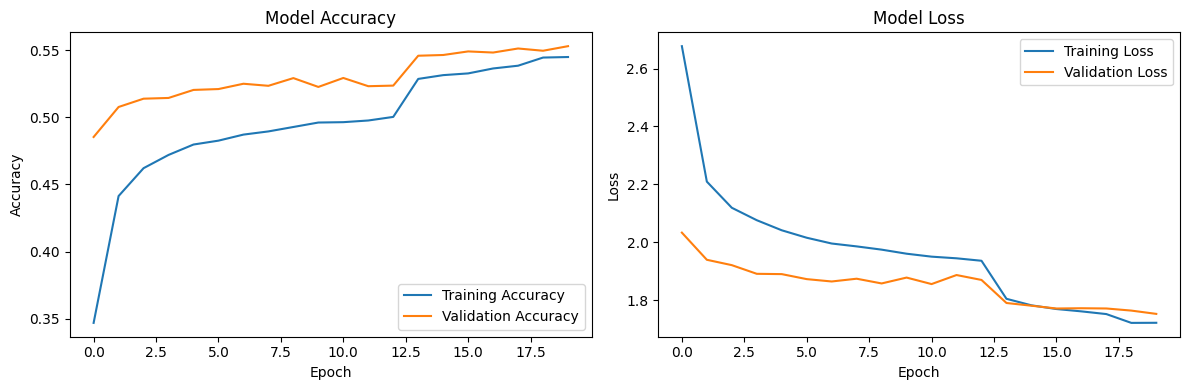

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

def preprocess_data(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = image / 255.0
    return image, label

def create_model(num_classes):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model

def train_model():
    print("Loading datasets from directory...")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        '/Users/uditbhardwaj/Documents/AndroidProjects/foodmacros/food-101/images',
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        subset="training",
        seed=123
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        '/Users/uditbhardwaj/Documents/AndroidProjects/foodmacros/food-101/images',
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        subset="validation",
        seed=123
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    # Shuffle train dataset!
    train_ds = train_ds.shuffle(buffer_size=1000).map(preprocess_data).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(preprocess_data).prefetch(tf.data.AUTOTUNE)

    # Sanity check labels
    print("\nSample training labels:")
    for images, labels in train_ds.take(1):
        print(labels.numpy())

    print("\nSample validation labels:")
    for images, labels in test_ds.take(1):
        print(labels.numpy())

    print("\nCreating model...")
    model, base_model = create_model(num_classes)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    print("\nStarting training...")
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=test_ds,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
        ]
    )

    print("\nFine-tuning model...")
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=10,
        validation_data=test_ds,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
        ]
    )

    # Save Keras model
    model.save('food_classifier_model.h5')

    # Convert to TensorFlow Lite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open('food_classifier.tflite', 'wb') as f:
        f.write(tflite_model)

    # Save class names
    with open('class_names.txt', 'w') as f:
        for name in class_names:
            f.write(f"{name}\n")

    print("\nTraining completed!")
    return model, history

def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

if __name__ == "__main__":
    model, history = train_model()
    plot_training_history(history)

In [14]:
!pip install seaborn



  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


# Code 2

In [ ]:

import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- Constants ---
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.0001
MODEL_NAME_PREFIX = "food_classifier_optimized"

# --- Data Preprocessing ---
def preprocess_data(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    return image, label

# --- Model Creation ---
def create_model(num_classes, base_trainable=False, unfreeze_last_n=None):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = base_trainable
    if base_trainable and unfreeze_last_n:
        for layer in base_model.layers[:-unfreeze_last_n]:
            layer.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# --- Load Data ---
def load_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        '/Users/uditbhardwaj/Documents/AndroidProjects/Model/food-101/images',
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        subset="training",
        seed=123
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        '/Users/uditbhardwaj/Documents/AndroidProjects/Model/food-101/images',
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        subset="validation",
        seed=123
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    train_ds = train_ds.map(preprocess_data).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(preprocess_data).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, class_names, num_classes

# --- Training ---
def train_and_finetune(model, train_ds, val_ds):
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print("Initial training...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, monitor='val_loss', min_lr=1e-5)
        ]
    )

    # --- Fine-tuning ---
    print("\nFine-tuning last 30 layers...")
    model.trainable = True
    for layer in model.layers[1].layers[:-30]:
        layer.trainable = False

    model.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    fine_tune_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ]
    )

    return model, history, fine_tune_history

# --- Save Model and Metadata ---
def save_model(model, class_names):
    model.save(f"{MODEL_NAME_PREFIX}.h5")
    print(f"Model saved as {MODEL_NAME_PREFIX}.h5")

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(f"{MODEL_NAME_PREFIX}.tflite", 'wb') as f:
        f.write(tflite_model)

    with open(f"class_names_{MODEL_NAME_PREFIX}.txt", 'w') as f:
        for name in class_names:
            f.write(f"{name}\n")

# --- Evaluation ---
def evaluate_model(model, val_ds, class_names):
    y_true = []
    y_pred = []
    for images, labels in val_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{MODEL_NAME_PREFIX}.png")
    plt.show()

# --- Plot Training History ---
def plot_history(history, fine_tune_history=None):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label="Train Acc")
    plt.plot(history.history['val_accuracy'], label="Val Acc")
    if fine_tune_history:
        plt.plot(
            range(len(history.history['accuracy']),
                  len(history.history['accuracy']) + len(fine_tune_history.history['accuracy'])),
            fine_tune_history.history['accuracy'], label="FT Train Acc")
        plt.plot(
            range(len(history.history['val_accuracy']),
                  len(history.history['val_accuracy']) + len(fine_tune_history.history['val_accuracy'])),
            fine_tune_history.history['val_accuracy'], label="FT Val Acc")

    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    if fine_tune_history:
        plt.plot(
            range(len(history.history['loss']),
                  len(history.history['loss']) + len(fine_tune_history.history['loss'])),
            fine_tune_history.history['loss'], label="FT Train Loss")
        plt.plot(
            range(len(history.history['val_loss']),
                  len(history.history['val_loss']) + len(fine_tune_history.history['val_loss'])),
            fine_tune_history.history['val_loss'], label="FT Val Loss")

    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"training_history_{MODEL_NAME_PREFIX}.png")
    plt.show()

# --- Main ---
if __name__ == "__main__":
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            tf.config.experimental.set_memory_growth(physical_devices[0], True)
            print("GPU is available and memory growth is enabled.")
        except:
            pass

    train_ds, val_ds, class_names, num_classes = load_datasets()
    model = create_model(num_classes)
    model, history, fine_tune_history = train_and_finetune(model, train_ds, val_ds)
    save_model(model, class_names)
    evaluate_model(model, val_ds, class_names)
    plot_history(history, fine_tune_history)